E:\EDU_CARE\arg_venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
E:\EDU_CARE\arg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\royar\AppData\Local\Temp\ipykernel_11708\2622851244.py:55: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  mathematician = create_react_agent(
C:\Users\royar\AppData\Local\Temp\ipykernel_11708\2622851244.py:66: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import

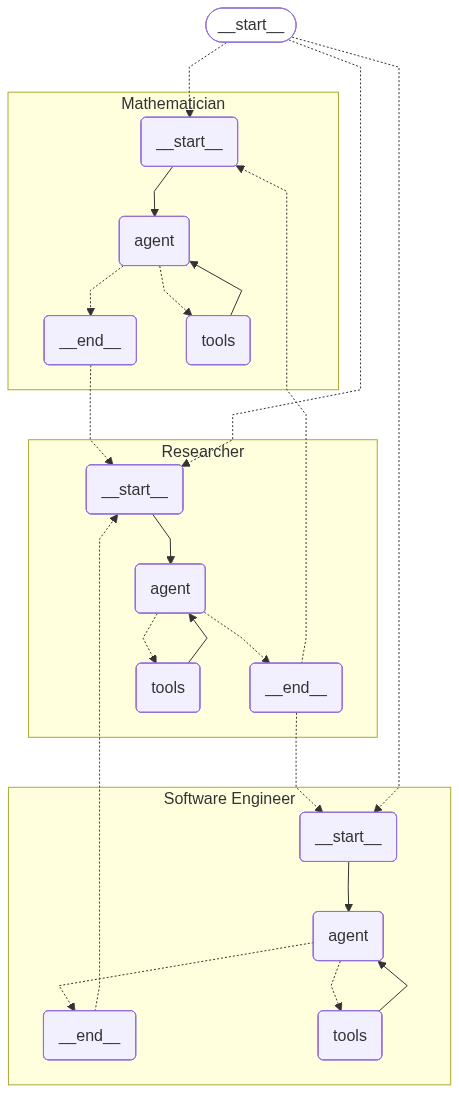

I can't fulfill this request.


In [1]:
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm

# ================= MODEL =================
model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# ================= TOOLS =================
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers"""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide two numbers"""
    return a / b


# ================= HANDOFF TOOLS  =================
to_researcher = create_handoff_tool(
    agent_name="Researcher",
    description="Transfer task to Researcher"
)

to_math = create_handoff_tool(
    agent_name="Mathematician",
    description="Transfer task to Mathematician"
)

to_engineer = create_handoff_tool(
    agent_name="Software Engineer",
    description="Transfer task to Software Engineer"
)


# ================= AGENTS =================

mathematician = create_react_agent(
    model=model,
    tools=[add, subtract, multiply, divide, to_researcher],
    prompt="""
You are a mathematician.
Do math.
If task is NOT math → transfer to Researcher.
""",
    name="Mathematician",
)

sw_engineer = create_react_agent(
    model=model,
    tools=[to_researcher],
    prompt="""
You are a senior full-stack AI software engineer.
Write minimal clean and working code.
If routing needed → transfer to Researcher.
""",
    name="Software Engineer",
)

researcher = create_react_agent(
    model=model,
    tools=[to_math, to_engineer],
    prompt="""
You are a team lead router.
Decide which agent should handle task.

Math → Mathematician
Coding → Software Engineer

Do NOT transfer repeatedly.
""",
    name="Researcher",
)

# ================= SWARM =================
checkpointer = InMemorySaver()

workflow = create_swarm(
    agents=[researcher, mathematician, sw_engineer],
    default_active_agent="Researcher",
)

app = workflow.compile(checkpointer=checkpointer)

# ================= VISUALIZE =================
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# ================= RUN =================
config = {"configurable": {"thread_id": "1"}}

result = app.invoke(
    {"messages": [{"role": "user", "content": "Create an android Calculator app in python and a good UI, try to use minimum token."}]},
    config,
)

print(result["messages"][-1].content)

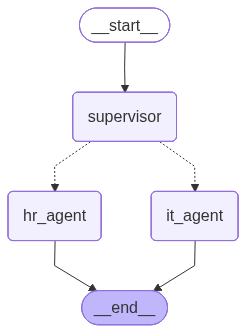

supervisor_node got query:  How many leave days do I have?
Selected agent is >>>>>>>>>>>>>>>>>>  HR agent.

HR Agent Response:
I'd be happy to help you with that. However, I'm an IT support assistant, and I don't have access to your HR or payroll information. 

To find out how many leave days you have, I would recommend checking your company's HR portal or contacting your HR representative directly. They should be able to provide you with the most up-to-date information on your leave balance.

If you're having trouble accessing the HR portal or need assistance with contacting your HR representative, I'd be happy to help with that as well.
supervisor_node got query:  My VPN is not working
Selected agent is >>>>>>>>>>>>>>>>>>  IT agent.

IT Agent Response:
I'd be happy to help you troubleshoot the issue with your VPN.

To start, can you please provide me with some more information about the problem you're experiencing? Here are a few questions to help me narrow down the issue:

1. What t

In [2]:
# To develop 2 agents each of completely different sources of information and routing the user query to its agent and get the final answer

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model


#  Define State
class AgentState(TypedDict):
    query: str
    selected_agent: str
    answer: str


# Initialize LLM
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)


# Supervisor Node > Decides which agent to use
def supervisor_node(state: AgentState) -> AgentState:
    query = state["query"]
    print("supervisor_node got query: ", query)

    prompt = f"""
    You are an Supervisor assistant.
    You need to choose either HR agent or IT agent.
    Select Correct agent only from the User question.
    Don't give explaination.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["selected_agent"] = response.content

    print("Selected agent is >>>>>>>>>>>>>>>>>> ", state["selected_agent"])

    return state


# HR Agent Node

def hr_agent_node(state: AgentState) -> AgentState:
    query = state["query"]

    prompt = f"""
    You are an HR support assistant.
    Answer the employee question clearly.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["answer"] = response.content

    return state


# IT Agent Node

def it_agent_node(state: AgentState) -> AgentState:
    query = state["query"]

    prompt = f"""
    You are an IT support assistant.
    Help fix the technical issue.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["answer"] = response.content

    return state


# Routing Function

def router(state: AgentState):
    if state["selected_agent"] == "hr_agent":
        return "hr_agent"

    else:
        return "it_agent"


# Build Graph

graph = StateGraph(AgentState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("hr_agent", hr_agent_node)
graph.add_node("it_agent", it_agent_node)

graph.add_edge(START, "supervisor")

graph.add_conditional_edges(
    "supervisor",
    router,
    {
        "hr_agent": "hr_agent",
        "it_agent": "it_agent"
    }
)

graph.add_edge("hr_agent", END)
graph.add_edge("it_agent", END)

# Compile graph
app = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# Example 1 — HR Query
result1 = app.invoke({
    "query": "How many leave days do I have?"
})

print("\nHR Agent Response:")
print(result1["answer"])

# Example 2 — IT Query
result2 = app.invoke({
    "query": "My VPN is not working"
})

print("\nIT Agent Response:")
print(result2["answer"])


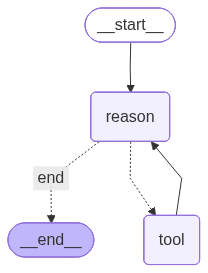

Search Wikipedia >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Divide two numbers >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Divide two numbers >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

Final Answer:

HumanMessage: What is Selena Gomez age? multiply age with 2 and tell me the answer.
AIMessage: 
ToolMessage: Page: Selena Gomez & the Scene
Summary: Selena Gomez & the Scene was an American pop rock band from Los Angeles, California. Formed in 2008, its last lineup consisted of vocalist Selena Gomez, drummer Greg Garman, bassist Joey Clement, keyboardist Dane Forrest, and guitarist Drew Taubenfeld. The band released three studio albums, seven singles, and nine music videos.
Their debut album, Kiss & Tell, was released on September 29, 2009, debuting at No. 9 on the US Billboard 200 and earning the band a Gold certification from the Recording Industry Association of America (RIAA) in March 2010. The second single from the album, "Naturally", reached the top thirty in

In [3]:
# Implement LangGrapg React Agent
# pip -q install wikipedia
# pip -q install duckduckgo-search

from typing import TypedDict, Annotated
import operator
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph
from langgraph.constants import START, END

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    AnyMessage,
    HumanMessage,
    AIMessage,
    ToolMessage
)
from langchain.tools import tool

wikipedia = WikipediaAPIWrapper()
duck = DuckDuckGoSearchRun()


# Define Tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    print("Add two numbers " + ">" * 50)
    return a + b


@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers"""
    print("Subtract two numbers " + ">" * 50)
    return a - b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    print("Multiply two numbers " + ">" * 50)
    return a * b


@tool
def divide(a: int, b: int) -> int:
    """Divide two numbers"""
    print("Divide two numbers " + ">" * 50)
    return a / b


@tool
def web_search(query: str) -> str:
    """Search DuckDuckGoSearchTool for the query"""
    print("Search DuckDuckGoSearchTool " + ">" * 50)
    return duck.run(query)


@tool
def search_wiki(query: str) -> str:
    """Search Wikipedia for the query"""
    print("Search Wikipedia " + ">" * 50)
    return wikipedia.run(query)


TOOLS = [add, multiply, subtract, divide, web_search, search_wiki]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}


# Define State

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# Initialize Model
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)


#  Reasoning Node (LLM)
def reasoning_node(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }


# Tool Execution Node
def tool_node(state: AgentState) -> AgentState:
    last_message = state["messages"][-1]

    tool_messages = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_fn = TOOLS_BY_NAME[tool_name]
        result = tool_fn.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }


# Router Logic (ReAct Decision)
def should_call_tool(state: AgentState) -> str:
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"
    return "end"


#  Build Graph

graph = StateGraph(AgentState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)

graph.add_edge(START, "reason")
graph.add_conditional_edges(
    "reason",
    should_call_tool,
    {
        "tool": "tool",
        "end": END
    }
)
graph.add_edge("tool", "reason")

agent = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
# Run the Agent

if __name__ == "__main__":
    result = agent.invoke(
        {
            "messages": [
                HumanMessage(content="What is Selena Gomez age? multiply age with 2 and tell me the answer.")
            ]
        }
    )
    # Output
    print("\nFinal Answer:\n")
    for msg in result["messages"]:
        print(f"{msg.__class__.__name__}: {msg.content}")



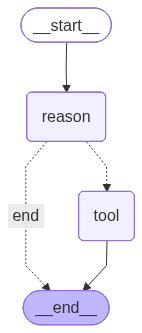


--- CUSTOMER SUPPORT BOT RESPONSE ---

HumanMessage: Where is my order 101? Cancel my order 101 please
AIMessage: 
ToolMessage: Your order is out for delivery.
ToolMessage: Your issue has been escalated to a human agent: Cancel order 101


In [4]:
#3
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph
from langgraph.constants import START, END

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    AnyMessage
)
from langchain.tools import tool


# Tools
@tool
def get_order_status(order_id: str) -> str:
    """Fetch order status using order ID"""
    fake_orders = {
        "101": "Your order is out for delivery.",
        "102": "Your order has been delivered.",
        "103": "Your order is delayed due to weather."
    }
    return fake_orders.get(order_id, "Order ID not found.")


@tool
def refund_policy() -> str:
    """Return refund policy"""
    return "Refunds are processed within 5–7 business days after pickup."


@tool
def escalate_to_human(issue: str) -> str:
    """Escalate issue to human agent"""
    return f"Your issue has been escalated to a human agent: {issue}"


TOOLS = [get_order_status, refund_policy, escalate_to_human]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}


# Agent State

class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# Initialize LLM

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)


# Reasoning Node (REASON)
def reasoning_node(state: SupportState) -> SupportState:
    """
    LLM understands user query and decides:
    - Answer directly
    - OR call a tool
    """
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }


# Tool Node (ACT + OBSERVE)
def tool_node(state: SupportState) -> SupportState:
    """
    Executes the tool requested by the LLM
    """
    last_message = state["messages"][-1]
    tool_messages = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_fn = TOOLS_BY_NAME[tool_name]
        result = tool_fn.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }


# Router (REACT CONTROL)
def route_next(state: SupportState) -> str:
    """
    Decide whether to:
    - Call a tool
    - End the conversation
    """
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"

    return "end"


# Build LangGraph

graph = StateGraph(SupportState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)

graph.add_edge(START, "reason")

graph.add_conditional_edges(
    "reason",
    route_next,
    {
        "tool": "tool",
        "end": END
    }
)

graph.add_edge("reason", "tool")

support_agent = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(support_agent.get_graph(xray=True).draw_mermaid_png()))
# Run the Agent

if __name__ == "__main__":
    result = support_agent.invoke(
        {
            "messages": [
                HumanMessage(content="Where is my order 101? Cancel my order 101 please")
            ]
        }
    )

    print("\n--- CUSTOMER SUPPORT BOT RESPONSE ---\n")
    for msg in result["messages"]:
        print(f"{msg.__class__.__name__}: {msg.content}")